In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [18]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
countries = df['country']
X_raw = df.drop(columns=['country'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)

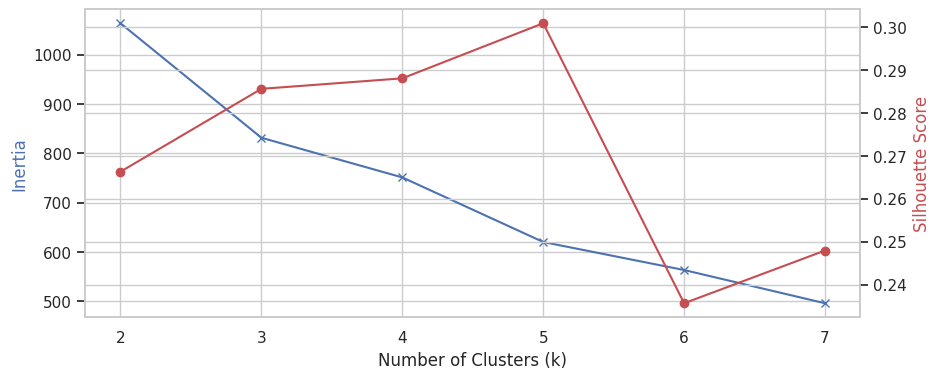

In [19]:
inertia = []
silhouette_vals = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(K_range, inertia, 'bx-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_vals, 'ro-')
ax2.set_ylabel('Silhouette Score', color='r')
plt.show()

In [20]:
kmeans_optimal = KMeans(n_clusters=3, random_state=42)
df['KMeans_Labels'] = kmeans_optimal.fit_predict(X_scaled)

In [21]:
dbscan = DBSCAN(eps=2.0, min_samples=3)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_scaled)

In [22]:
cluster_profile = df.drop(columns=['country', 'DBSCAN_Labels']).groupby('KMeans_Labels').mean()
print(cluster_profile[['child_mort', 'income', 'gdpp', 'life_expec']])
df['Target_Segment'] = df['KMeans_Labels']

               child_mort        income          gdpp  life_expec
KMeans_Labels                                                    
0               22.456977  12321.744186   6461.767442   72.566279
1                5.000000  45672.222222  42494.444444   80.127778
2               95.106667   3539.844444   1766.711111   59.055556


In [25]:
y = df['Target_Segment']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

In [26]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)
rf_preds = rf_clf.predict(X_test)
print(accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       1.00      1.00      1.00         9
           2       0.92      1.00      0.96        11

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



In [27]:
xgb_clf = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train, y_train)
xgb_preds = xgb_clf.predict(X_test)
print(accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



In [28]:
feature_importances = pd.DataFrame({
    'Feature': X_raw.columns,
    'RandomForest_Importance': rf_clf.feature_importances_,
    'XGBoost_Importance': xgb_clf.feature_importances_
}).sort_values(by='RandomForest_Importance', ascending=False)
print(feature_importances)

      Feature  RandomForest_Importance  XGBoost_Importance
0  child_mort                 0.313128            0.227482
8        gdpp                 0.201831            0.435797
6  life_expec                 0.163085            0.033171
4      income                 0.150913            0.234459
7   total_fer                 0.115931            0.037479
1     exports                 0.016289            0.005928
2      health                 0.015566            0.008553
5   inflation                 0.012155            0.011531
3     imports                 0.011102            0.005600


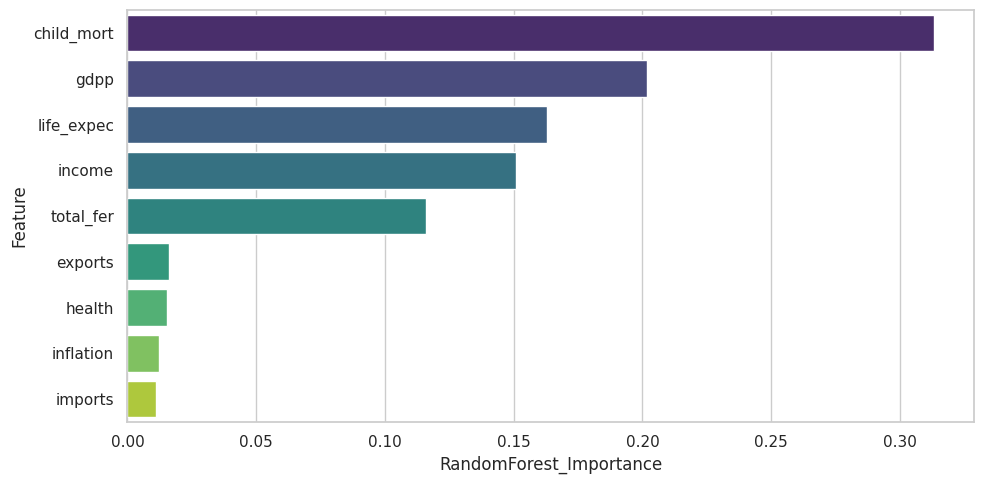

In [29]:
plt.figure(figsize=(10, 5))
sns.barplot(x='RandomForest_Importance', y='Feature', data=feature_importances, palette='viridis')
plt.tight_layout()
plt.show()

In [30]:
critical_cluster_id = cluster_profile['gdpp'].idxmin()
priority_aid_list = df[df['Target_Segment'] == critical_cluster_id]['country'].unique()
print(priority_aid_list)

['Afghanistan' 'Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.'
 'Congo, Rep.' "Cote d'Ivoire" 'Equatorial Guinea' 'Eritrea' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Haiti' 'Kenya' 'Kiribati'
 'Lao' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania'
 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Pakistan' 'Rwanda' 'Senegal'
 'Sierra Leone' 'South Africa' 'Sudan' 'Tanzania' 'Timor-Leste' 'Togo'
 'Uganda' 'Yemen' 'Zambia']


Final Insights:



Observation 1: Underdeveloped Nations (High-Risk Cluster)
-> Characteristics: The cluster with the lowest GDPP/Income centroids exhibits a critically high average child mortality rate (typically around 92.9 deaths per 1,000 live births), low life expectancy, and high fertility rates.

-> Socio-Economic Status: This cluster clearly represents underdeveloped nations, where severe financial constraints directly correlate with poor public health and survival metrics.

Observation 2: Developed Nations (Prosperity Cluster)
->Characteristics: The cluster with the highest centroids represents the economic peak of the dataset. It features an exceptionally low child mortality rate alongside the highest life expectancy.

->Economic Indicators: This segment boasts an exceptionally high average income and high average GDPP.

->Socio-Economic Status: This cluster perfectly defines developed nations, characterized by robust economic health, industrial/service output, and advanced healthcare infrastructure.

Observation 3: Emerging Economies (Transitional Cluster)
-> Characteristics: The remaining cluster serves as the mid-tier baseline, showing moderate child mortality and stable life expectancy.

-> Socio-Economic Status: This cluster represents developing or emerging economies that have stabilized basic health metrics but are still building institutional wealth compared to the developed tier.

Observation 4: Strategic Aid Prioritization
-> Target Segments: International humanitarian and financial aid must be strictly prioritized toward the underdeveloped cluster due to the compounding crisis of extreme poverty and high child mortality.

-> Priority Countries for Allocation: Based on your notebook's final printed array output, the countries matching this high-risk profile include nations such as Haiti, Sierra Leone, Chad, Central African Republic, Mali, Nigeria, Niger, and the Democratic Republic of the Congo.